In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

--- SVM Kernel Comparison ---


/run/media/orado-wise/MyData/PYTHON/ML/JupyterWorkspace/myenv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



Kernel: LINEAR
Accuracy:  0.8521
Precision: 0.0000
Recall:    0.0000
AUC:       0.2667


/run/media/orado-wise/MyData/PYTHON/ML/JupyterWorkspace/myenv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



Kernel: RBF
Accuracy:  0.8914
Precision: 0.8387
Recall:    0.3291
AUC:       0.7636


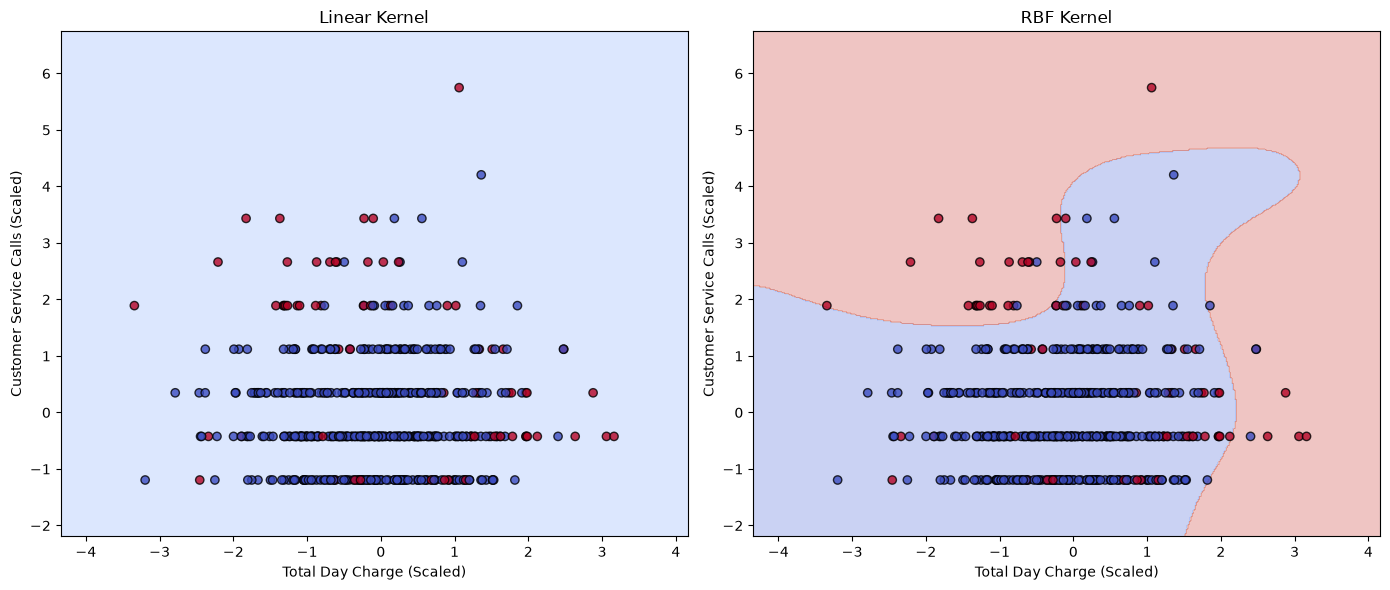

In [2]:
svm_df = pd.read_csv('churn-bigml-80.csv')

le_svm = LabelEncoder()
svm_df['Churn'] = le_svm.fit_transform(svm_df['Churn'])


X_svm = svm_df[['Total day charge', 'Customer service calls']]
y_svm = svm_df['Churn']


X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_svm, y_svm, test_size=0.2, random_state=42)


scaler_s = StandardScaler()
X_train_scaled = scaler_s.fit_transform(X_train_s)
X_test_scaled = scaler_s.transform(X_test_s)


kernels = ['linear', 'rbf']
trained_models = {}

print("--- SVM Kernel Comparison ---")
for k in kernels:
    
    svm_model = SVC(kernel=k, probability=True, random_state=42)
    svm_model.fit(X_train_scaled, y_train_s)
    trained_models[k] = svm_model
  
    y_pred = svm_model.predict(X_test_scaled)
    y_prob = svm_model.predict_proba(X_test_scaled)[:, 1]
    
    
    print(f"\nKernel: {k.upper()}")
    print(f"Accuracy:  {accuracy_score(y_test_s, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test_s, y_pred, zero_division=0):.4f}")
    print(f"Recall:    {recall_score(y_test_s, y_pred):.4f}")
    print(f"AUC:       {roc_auc_score(y_test_s, y_prob):.4f}")


def plot_decision_boundary(model, X, y, title, ax):
 
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='coolwarm', alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel('Total Day Charge (Scaled)')
    ax.set_ylabel('Customer Service Calls (Scaled)')


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_decision_boundary(trained_models['linear'], X_test_scaled, y_test_s, "Linear Kernel", axes[0])
plot_decision_boundary(trained_models['rbf'], X_test_scaled, y_test_s, "RBF Kernel", axes[1])

plt.tight_layout()
plt.show()